# Regresión Lineal HV v9 — EDA, preprocesamiento y simulador de escenarios

Este notebook aplica regresión lineal para analizar la productividad de equipos harvester usando únicamente las variables definidas en el documento del proyecto. La lógica es clara: primero se entiende el dato, luego se prepara de forma controlada, después se entrena el modelo y finalmente se usa como simulador de escenarios para comparar equipos bajo las mismas condiciones.


## 1. Librerías y configuración
Se cargan las librerías necesarias para análisis, gráficos, preprocesamiento, modelado y evaluación.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42


## 2. Carga del dataset
El archivo se carga desde local, Colab o GitHub RAW. Esto permite ejecutar el notebook en diferentes entornos sin cambiar el código.


In [2]:
FILE_NAME = "Dataset_HV_2026_v2.xlsx"
GITHUB_URL = "https://raw.githubusercontent.com/RolandoLopez16/RegresionLinealHV/main/Dataset_HV_2026_v2.xlsx"

possible_paths = [
    f"/mnt/data/{FILE_NAME}",
    FILE_NAME,
    f"./{FILE_NAME}",
    f"/content/{FILE_NAME}",
]

DATA_PATH = next((p for p in possible_paths if os.path.exists(p)), None)

if DATA_PATH is not None:
    print(f"Dataset cargado desde archivo local: {DATA_PATH}")
    df = pd.read_excel(DATA_PATH)
else:
    print("Dataset local no encontrado. Cargando desde GitHub RAW...")
    DATA_PATH = GITHUB_URL
    df = pd.read_excel(DATA_PATH)

print(f"Fuente utilizada: {DATA_PATH}")
print(f"Dimensiones iniciales: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Dataset cargado desde archivo local: /mnt/data/Dataset_HV_2026_v2.xlsx


Fuente utilizada: /mnt/data/Dataset_HV_2026_v2.xlsx
Dimensiones iniciales: 1645 filas x 64 columnas


,E%,E% Global,DM%,ARB/HORA,VOL/ÁRBOL,PRODUCTIVIDAD M3/H,T EFECTIVO,Horas disponibles,Ttal P. mec,Mantenimiento periódico,T Paradas Mec Mantenimiento,Total horas de otras paradas,EQUIPO,MARCA,OPERADOR,CEDULA,ZONA,CONTRATISTA,FECHA,FINCA,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,clima_presion_promedio_dia_hpa,clima_horas_validas_dia,clima_horas_lluvia_dia,Longitud Sexa finca,Latitud Sexa finca,Municipio Finca,PENDIENTE PROMEDIO FINCA,ESPECIE,LOTE,TURNO,HORA INICIO TURNO,HORA FIN TURNO,PENDIENTE,TOTAL DE ARBOLES,M3,M3/HORA,FUSTES/HORA,DIAMETRO,T PROGRAMADO,T PARADAS MEC,ESPECIFICACION PARADA,REF REPUESTO,ALISTAMIENTO,TANQUEO,ALIMENTACIÓN,T USO WINCHE,NOVEDADES,SUELO,HORAS DE OTRAS PARADA,T OTRA PARADA 1,T OTRA PARADA2,T OTRA PARADA3,T OTRA PARADA 4,T OTRA PARADA 5,MOTIVO 1,MOTIVO 2,MOTIVO 3,MOTIVO 4,MOTIVO 5
0,0.000,0.000,1.000,NaN,NaN,NaN,0.000,8.000,0.000,0.000,0.000,8.000,HVPO-1,PONSSE,ELBER GRANADA,"15,961,194.000",NORTE,GREEN FOREST,2026-01-01,13INDOS,17.400,12.900,22.900,22.100,10.000,0.000,0,0,75°50'28.7''W,4°10'32.5''N,Sevilla,29.075,Eucalyptus grandis,15,TURNO 1,06:00:00,14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INOPERATIVO POR PASO DE LÍQUIDO REFRIGERANTE A...,HUMEDO,8.000,8.000,NaN,NaN,NaN,NaN,Receso Año nuevo,NaN,NaN,NaN,NaN
1,0.000,0.000,1.000,NaN,NaN,NaN,0.000,7.000,0.000,0.000,0.000,7.000,HVPO-1,PONSSE,JOSE MORENO,"94,282,613.000",NORTE,GREEN FOREST,2026-01-01,13INDOS,17.400,12.900,22.900,22.100,10.000,0.000,0,0,75°50'28.7''W,4°10'32.5''N,Sevilla,29.075,Eucalyptus grandis,15,TURNO 2,14:00:00,22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,7.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INOPERATIVO POR PASO DE LÍQUIDO REFRIGERANTE A...,HUMEDO,7.000,7.000,NaN,NaN,NaN,NaN,Receso Año nuevo,NaN,NaN,NaN,NaN
2,0.000,0.000,1.000,NaN,NaN,NaN,0.000,8.000,0.000,0.000,0.000,8.000,HVPO-5,PONSSE,NAPOLEON OROZCO,"94,266,396.000",NORTE,GREEN FOREST,2026-01-01,13CRIST,15.200,10.700,20.100,13.300,8.500,0.000,0,0,75°51'47.2''W,4°07'04.0''N,Sevilla,35.031,Pinus maximinoi,8,TURNO 1,06:00:00,14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OPERADOR EN DIA DE RECESO POR NAVIDAD,HUMEDO,8.000,8.000,NaN,NaN,NaN,NaN,Receso Año nuevo,NaN,NaN,NaN,NaN
3,0.000,0.000,1.000,NaN,NaN,NaN,0.000,7.000,0.000,0.000,0.000,7.000,HVPO-5,PONSSE,JORGE HERNANDEZ,"1,059,706,760.000",NORTE,GREEN FOREST,2026-01-01,13CRIST,15.200,10.700,20.100,13.300,8.500,0.000,0,0,75°51'47.2''W,4°07'04.0''N,Sevilla,35.031,Pinus maximinoi,8,TURNO 2,14:00:00,22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,7.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OPERADOR EN DIA DE RECESO POR NAVIDAD,HUMEDO,7.000,7.000,NaN,NaN,NaN,NaN,Receso Año nuevo,NaN,NaN,NaN,NaN
4,0.000,0.000,0.000,NaN,NaN,NaN,0.000,0.000,8.000,0.000,0.000,0.000,HVPO-1,PONSSE,ELBER GRANADA,"15,961,194.000",NORTE,GREEN FOREST,2026-01-02,13INDOS,17.400,12.900,22.900,22.100,10.000,0.000,0,0,75°50'28.7''W,4°10'32.5''N,Sevilla,29.075,Eucalyptus grandis,15,TURNO 1,06:00:00,14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,8.000,8.000,NaN,NaN,NaN,NaN,NaN,NaN,INOPERATIVO POR PASO DE LÍQUIDO REFRIGERANTE A...,HUMEDO,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Variables definidas por criterio de negocio
Se usan solo las variables señaladas en el documento para evitar que el modelo aprenda ruido o memorice ubicaciones específicas.


In [3]:
variables_categoricas = [
    "EQUIPO",
    "MARCA",
    "ZONA",
    "CONTRATISTA",
    "ESPECIE",
    "TURNO",
    "SUELO",
]

variables_numericas = [
    "PENDIENTE PROMEDIO FINCA",
    "TOTAL DE ARBOLES",
    "DIAMETRO",
    "T PROGRAMADO",
    "HORAS DE OTRAS PARADA",
    "clima_temp_promedio_dia_c",
    "clima_temp_min_dia_c",
    "clima_temp_max_dia_c",
    "clima_precipitacion_dia_mm",
    "clima_viento_promedio_dia_kmh",
]

target = "M3/HORA"

columnas_requeridas = variables_categoricas + variables_numericas + [target]
columnas_faltantes = [c for c in columnas_requeridas if c not in df.columns]

if columnas_faltantes:
    raise ValueError(f"Faltan columnas requeridas en el dataset: {columnas_faltantes}")

print("Todas las columnas requeridas están disponibles.")


Todas las columnas requeridas están disponibles.


## 4. Construcción del dataset de modelado
Se crea una tabla de trabajo únicamente con las variables aprobadas para el análisis.


In [4]:
df_model = df[columnas_requeridas].copy()

print(f"Dataset de modelado: {df_model.shape[0]} filas x {df_model.shape[1]} columnas")
df_model.head()


Dataset de modelado: 1645 filas x 18 columnas


,EQUIPO,MARCA,ZONA,CONTRATISTA,ESPECIE,TURNO,SUELO,PENDIENTE PROMEDIO FINCA,TOTAL DE ARBOLES,DIAMETRO,T PROGRAMADO,HORAS DE OTRAS PARADA,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,M3/HORA
0,HVPO-1,PONSSE,NORTE,GREEN FOREST,Eucalyptus grandis,TURNO 1,HUMEDO,29.075,NaN,NaN,8.000,8.000,17.400,12.900,22.900,22.100,10.000,NaN
1,HVPO-1,PONSSE,NORTE,GREEN FOREST,Eucalyptus grandis,TURNO 2,HUMEDO,29.075,NaN,NaN,7.000,7.000,17.400,12.900,22.900,22.100,10.000,NaN
2,HVPO-5,PONSSE,NORTE,GREEN FOREST,Pinus maximinoi,TURNO 1,HUMEDO,35.031,NaN,NaN,8.000,8.000,15.200,10.700,20.100,13.300,8.500,NaN
3,HVPO-5,PONSSE,NORTE,GREEN FOREST,Pinus maximinoi,TURNO 2,HUMEDO,35.031,NaN,NaN,7.000,7.000,15.200,10.700,20.100,13.300,8.500,NaN
4,HVPO-1,PONSSE,NORTE,GREEN FOREST,Eucalyptus grandis,TURNO 1,HUMEDO,29.075,NaN,NaN,8.000,8.000,17.400,12.900,22.900,22.100,10.000,NaN


## 5. Diagnóstico inicial de calidad
Se revisan tipos de datos, valores faltantes y duplicados antes de cualquier transformación.


In [5]:
resumen_calidad = pd.DataFrame({
    "tipo_dato": df_model.dtypes.astype(str),
    "nulos": df_model.isna().sum(),
    "%_nulos": (df_model.isna().mean() * 100).round(2),
    "unicos": df_model.nunique(dropna=True)
}).sort_values(by="%_nulos", ascending=False)

print("Duplicados exactos:", df_model.duplicated().sum())
resumen_calidad


Duplicados exactos: 160


,tipo_dato,nulos,%_nulos,unicos
DIAMETRO,float64,654,39.760,221
TOTAL DE ARBOLES,float64,382,23.220,527
M3/HORA,float64,376,22.860,794
SUELO,object,65,3.950,4
T PROGRAMADO,float64,4,0.240,16
TURNO,object,2,0.120,6
MARCA,object,0,0.000,2
EQUIPO,object,0,0.000,10
ESPECIE,object,0,0.000,10
CONTRATISTA,object,0,0.000,3


## 6. Limpieza básica de texto y tipos
Se normalizan categorías y se convierten variables numéricas para evitar errores por formatos inconsistentes.


In [6]:
for col in variables_categoricas:
    df_model[col] = (
        df_model[col]
        .astype("string")
        .str.strip()
        .str.upper()
        .replace({"": np.nan, "NAN": np.nan, "NONE": np.nan, "NULL": np.nan})
    )

for col in variables_numericas + [target]:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

filas_antes = len(df_model)
df_model = df_model.dropna(subset=[target])
print("Filas eliminadas por target nulo:", filas_antes - len(df_model))

filas_antes = len(df_model)
df_model = df_model.drop_duplicates()
print("Duplicados eliminados:", filas_antes - len(df_model))

print("Dimensiones después de limpieza básica:", df_model.shape)


Filas eliminadas por target nulo: 376
Duplicados eliminados: 9
Dimensiones después de limpieza básica: (1260, 18)


## 7. Validación operativa de la variable objetivo
La productividad debe ser positiva. Valores iguales o menores a cero no son útiles para este modelo.


In [7]:
filas_antes = len(df_model)
df_model = df_model[df_model[target] > 0].copy()
print("Registros eliminados por productividad <= 0:", filas_antes - len(df_model))
print("Dimensiones:", df_model.shape)


Registros eliminados por productividad <= 0: 6
Dimensiones: (1254, 18)


## 8. EDA de la productividad
Se revisa la distribución de la variable objetivo para identificar dispersión, sesgo y posibles valores extremos.


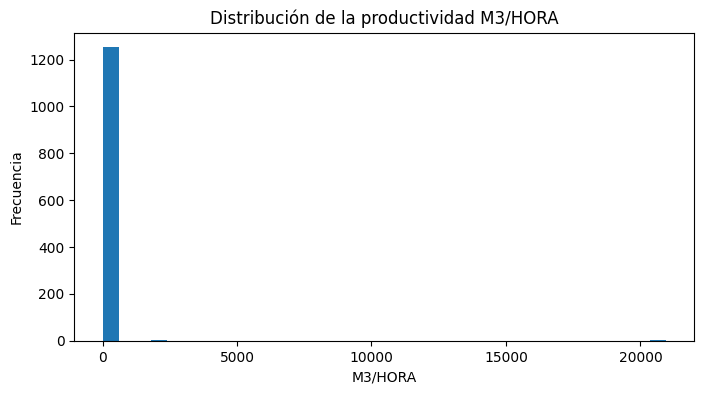

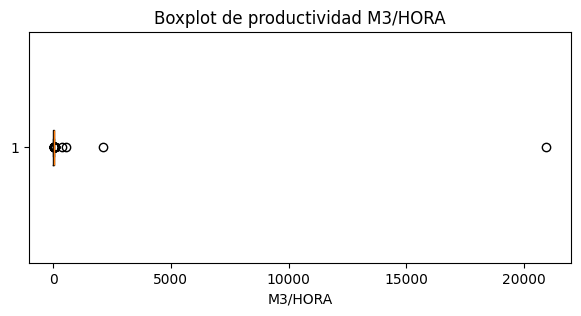

count    1,254.000
mean        34.213
std        594.767
min          0.360
25%          9.600
50%         13.700
75%         19.000
max     20,961.000
Name: M3/HORA, dtype: float64

In [8]:
plt.figure(figsize=(8,4))
plt.hist(df_model[target], bins=35)
plt.title("Distribución de la productividad M3/HORA")
plt.xlabel("M3/HORA")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(7,3))
plt.boxplot(df_model[target].dropna(), vert=False)
plt.title("Boxplot de productividad M3/HORA")
plt.xlabel("M3/HORA")
plt.show()

df_model[target].describe()


## 9. Análisis de outliers en productividad
Se identifican valores extremos mediante IQR. Para el modelo base se trabaja con el rango operacional típico, evitando que pocos extremos deformen la regresión lineal.


In [9]:
Q1 = df_model[target].quantile(0.25)
Q3 = df_model[target].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers_target = df_model[(df_model[target] < limite_inf) | (df_model[target] > limite_sup)]
print(f"Límite inferior: {limite_inf:.3f}")
print(f"Límite superior: {limite_sup:.3f}")
print("Outliers detectados en productividad:", len(outliers_target))

df_model = df_model[(df_model[target] >= limite_inf) & (df_model[target] <= limite_sup)].copy()
print("Dimensiones después de controlar outliers del target:", df_model.shape)


Límite inferior: -4.500
Límite superior: 33.100
Outliers detectados en productividad: 33
Dimensiones después de controlar outliers del target: (1221, 18)


## 10. EDA de variables numéricas
Se observa la distribución de cada variable numérica para comprender su escala y detectar comportamientos atípicos.


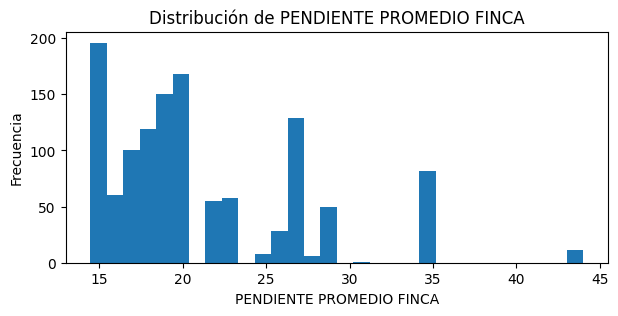

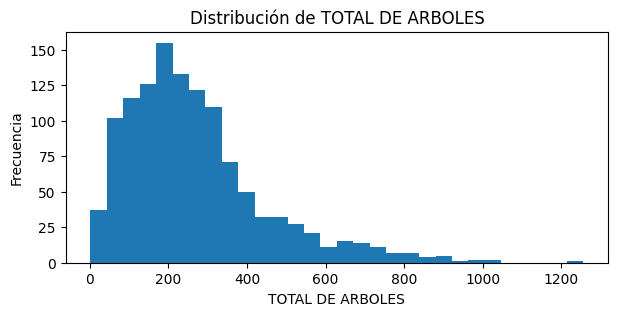

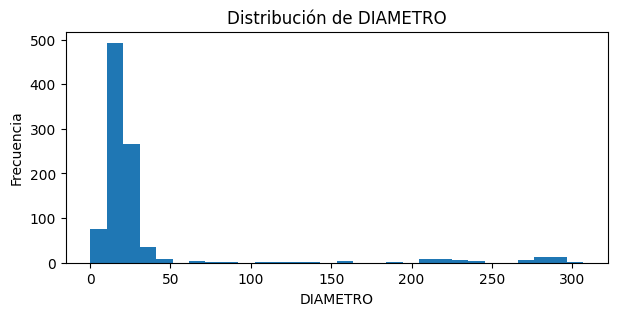

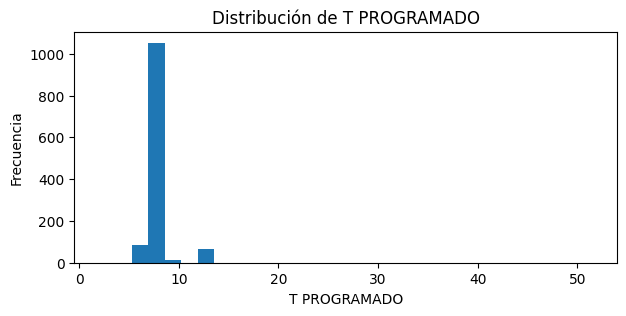

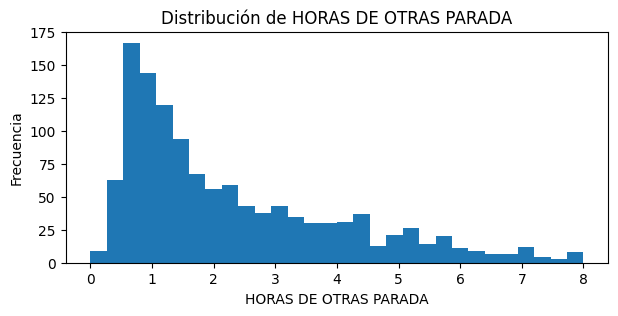

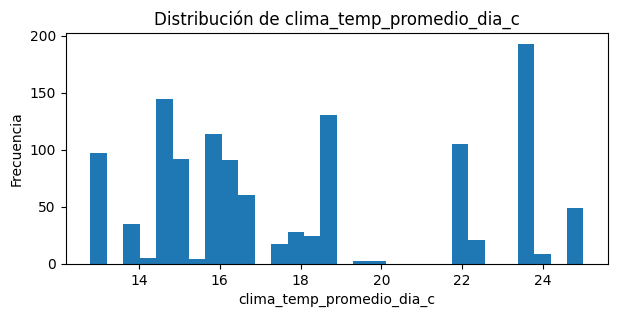

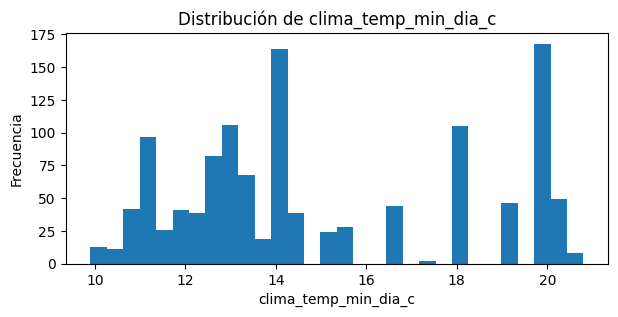

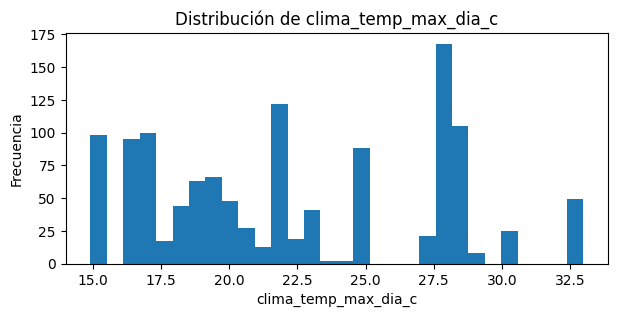

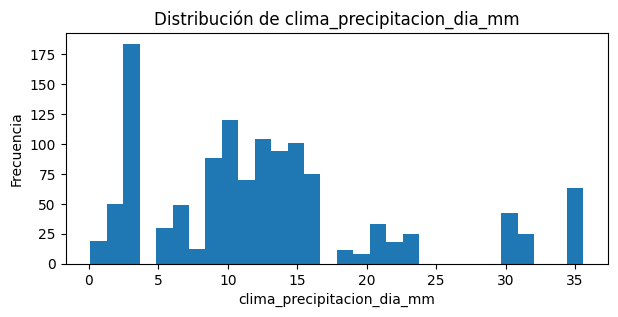

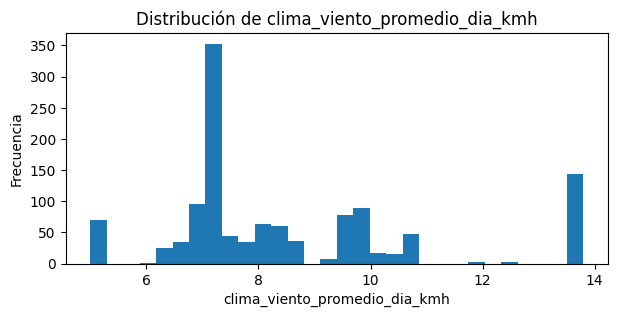

In [10]:
for col in variables_numericas:
    plt.figure(figsize=(7,3))
    plt.hist(df_model[col].dropna(), bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()


## 11. Relación numérica con productividad
Los gráficos de dispersión permiten revisar si la relación con la productividad parece lineal, débil o afectada por ruido operativo.


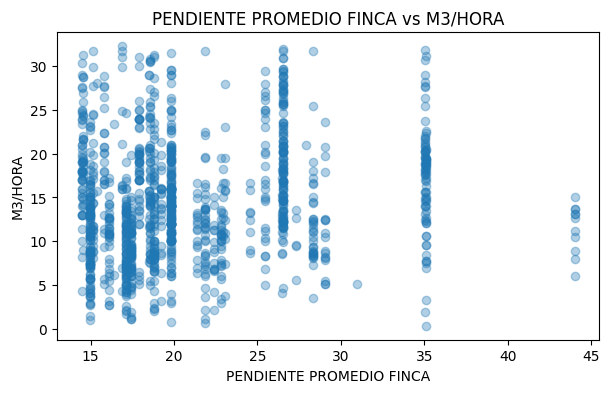

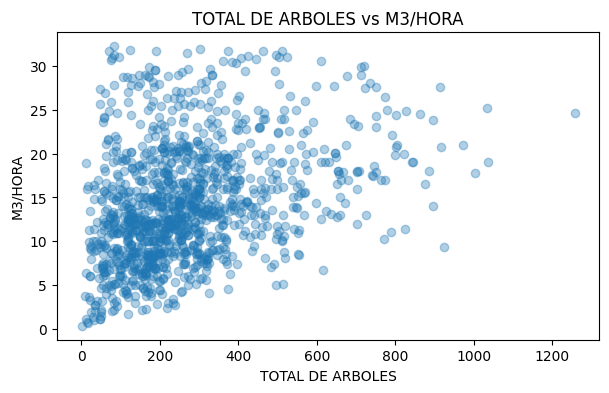

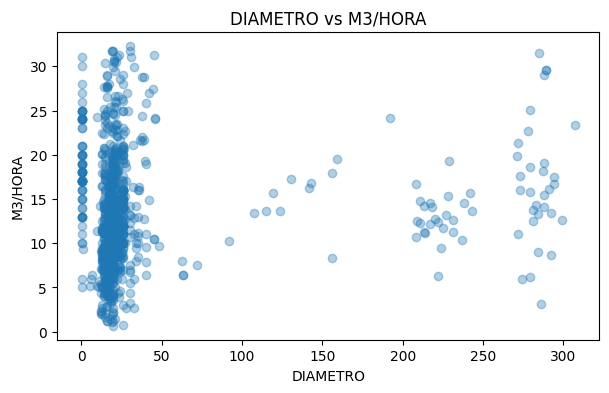

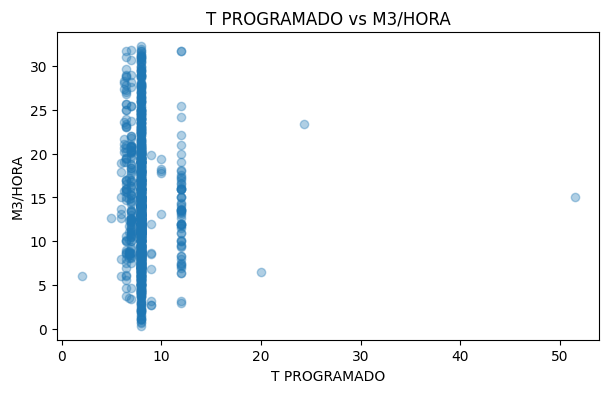

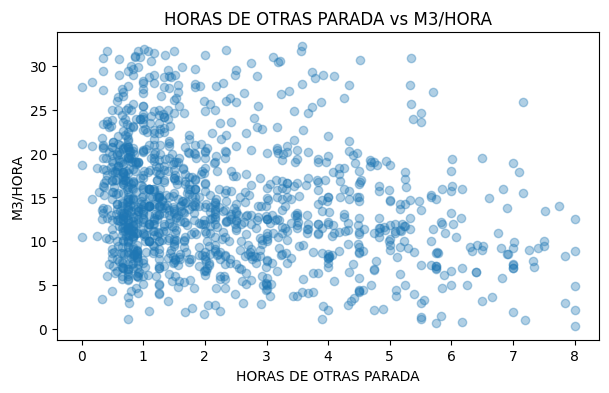

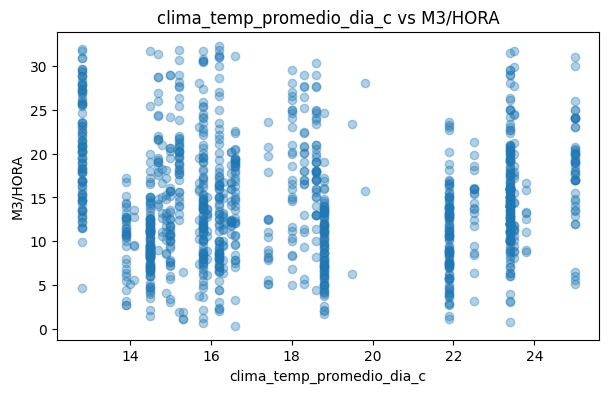

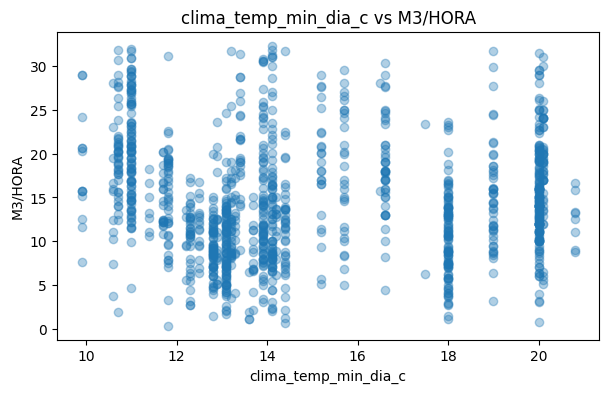

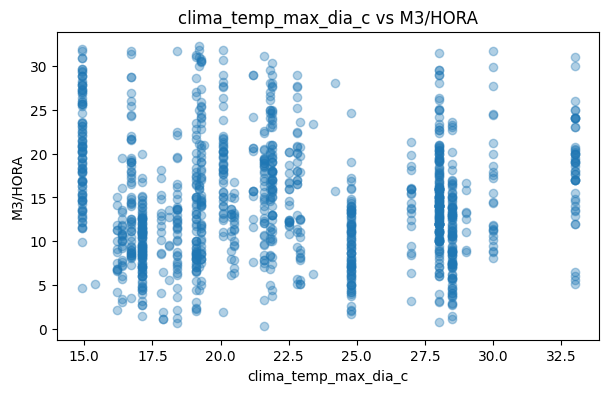

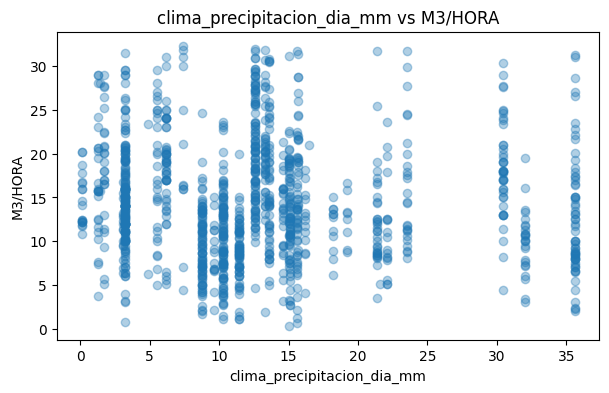

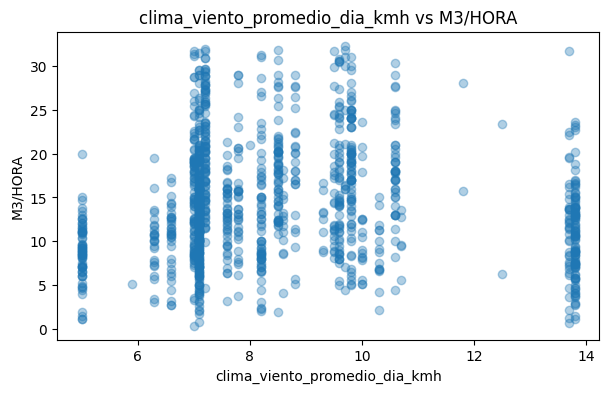

In [11]:
for col in variables_numericas:
    plt.figure(figsize=(7,4))
    plt.scatter(df_model[col], df_model[target], alpha=0.35)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()


## 12. Correlación entre variables numéricas
La matriz de correlación ayuda a detectar variables relacionadas entre sí y posibles problemas de multicolinealidad.


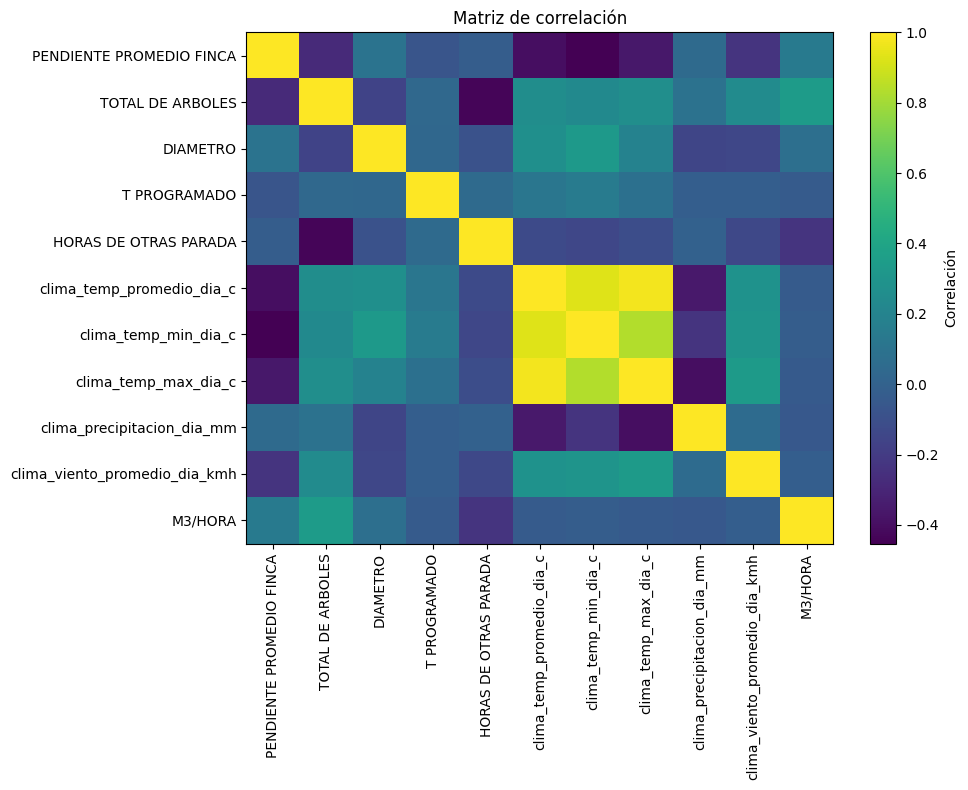

M3/HORA                          1.000
TOTAL DE ARBOLES                 0.347
PENDIENTE PROMEDIO FINCA         0.146
DIAMETRO                         0.080
clima_viento_promedio_dia_kmh   -0.021
clima_temp_min_dia_c            -0.024
clima_temp_promedio_dia_c       -0.034
T PROGRAMADO                    -0.035
clima_temp_max_dia_c            -0.044
clima_precipitacion_dia_mm      -0.053
HORAS DE OTRAS PARADA           -0.234
Name: M3/HORA, dtype: float64

In [12]:
corr = df_model[variables_numericas + [target]].corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlación")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

corr[target].sort_values(ascending=False)


## 13. EDA de variables categóricas
Se revisa la cardinalidad y la cantidad de registros por categoría. Esto es clave porque categorías con pocos datos pueden volver inestable la interpretación.



EQUIPO
Categorías: 10


,frecuencia
EQUIPO,
HVJD-5,170
HVJD-2,162
HVPO-5,140
HVJD-4,133
HVPO-3,124
HVJD-1,122
HVJD-3,100
HVPO-1,100
HVPO-2,91


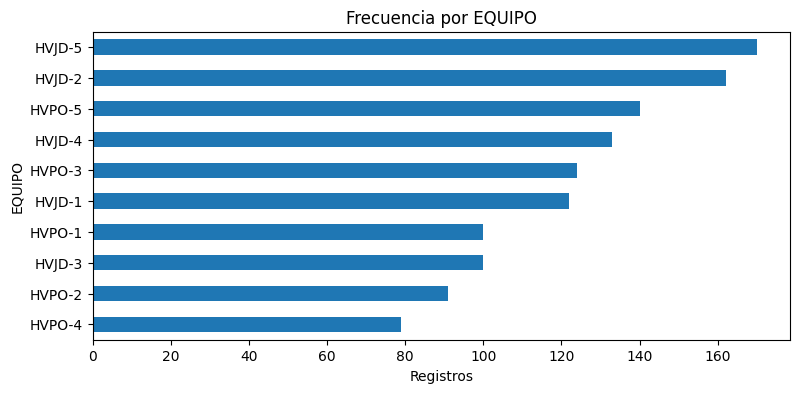


MARCA
Categorías: 2


,frecuencia
MARCA,
JOHN DEER,687
PONSSE,534


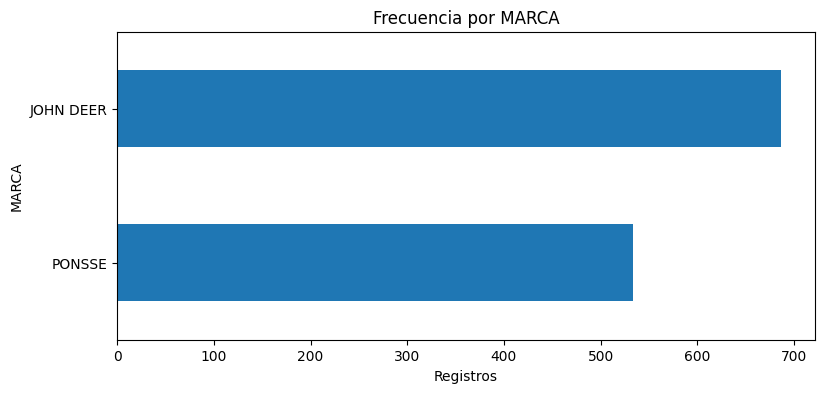


ZONA
Categorías: 3


,frecuencia
ZONA,
CENTRO,635
NORTE,481
SUR,105


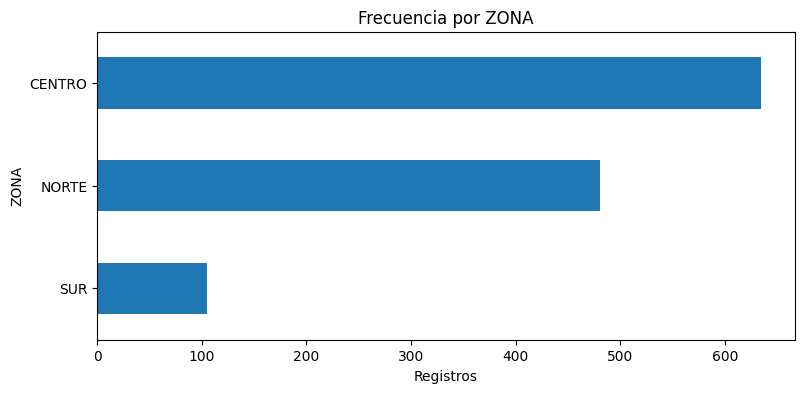


CONTRATISTA
Categorías: 3


,frecuencia
CONTRATISTA,
EFAGRAM,530
GREEN FOREST,436
AMBAR,255


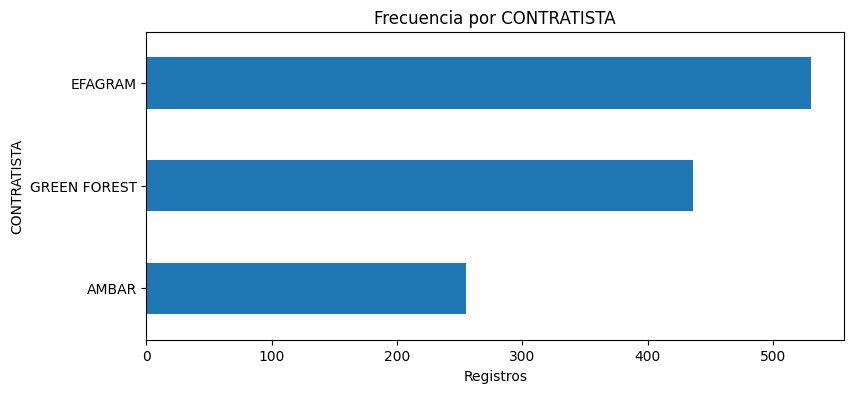


ESPECIE
Categorías: 10


,frecuencia
ESPECIE,
EUCALYPTUS GRANDIS,306
EUCALIPTO GRANDIS,206
PINO TECUNUMANII,194
PINUS TECUNUMANII,156
PINUS MAXIMINOI,103
EUCALIPTO UROGRANDIS,95
EUCALYPTUS UROGRANDIS,77
PINO PÁTULA,48
PINO MAXIMINO,21


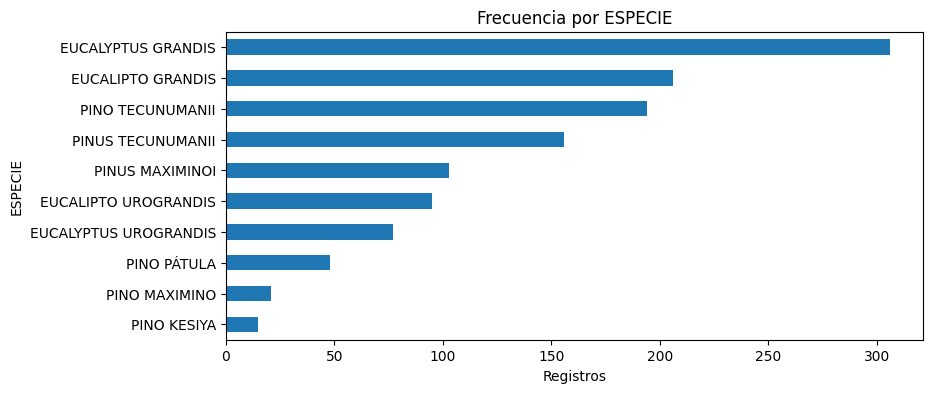


TURNO
Categorías: 3


,frecuencia
TURNO,
TURNO 1,641
TURNO 2,560
TURNO 3,20


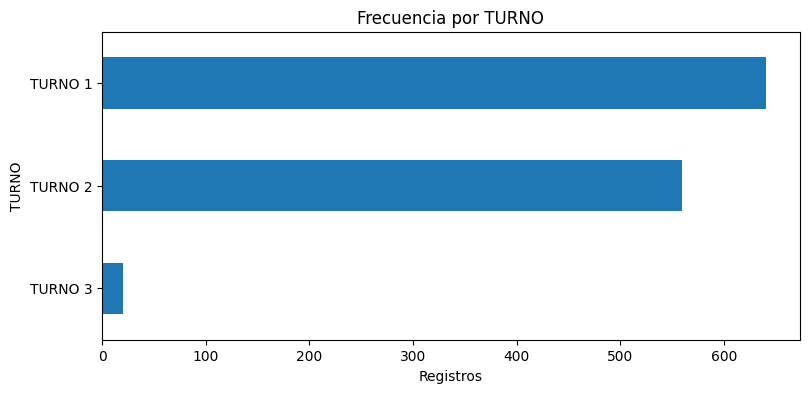


SUELO
Categorías: 2


,frecuencia
SUELO,
HUMEDO,737
SECO,463
<NA>,21


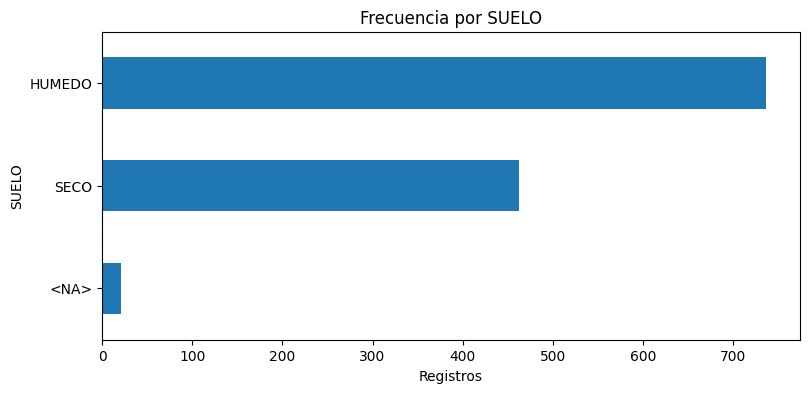

In [13]:
for col in variables_categoricas:
    conteo = df_model[col].value_counts(dropna=False)
    print("\n", "="*80)
    print(col)
    print("Categorías:", df_model[col].nunique(dropna=True))
    display(conteo.head(15).to_frame("frecuencia"))

    plt.figure(figsize=(9,4))
    conteo.head(12).sort_values().plot(kind="barh")
    plt.title(f"Frecuencia por {col}")
    plt.xlabel("Registros")
    plt.ylabel(col)
    plt.show()


## 14. Productividad por variable categórica
Los boxplots muestran diferencias de productividad por equipo, marca, zona, contratista, especie, turno y suelo.


<Figure size 1100x500 with 0 Axes>

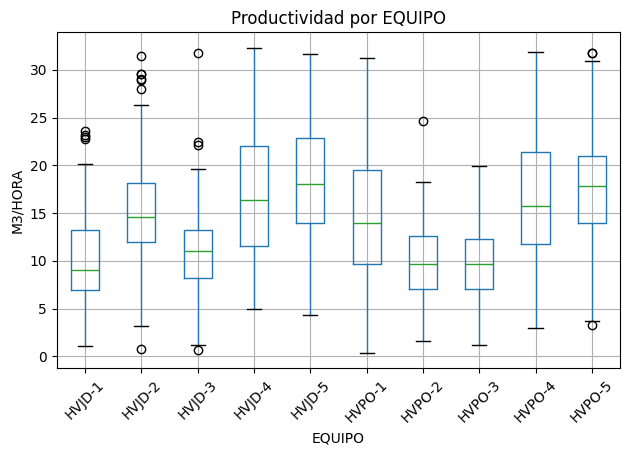

<Figure size 1100x500 with 0 Axes>

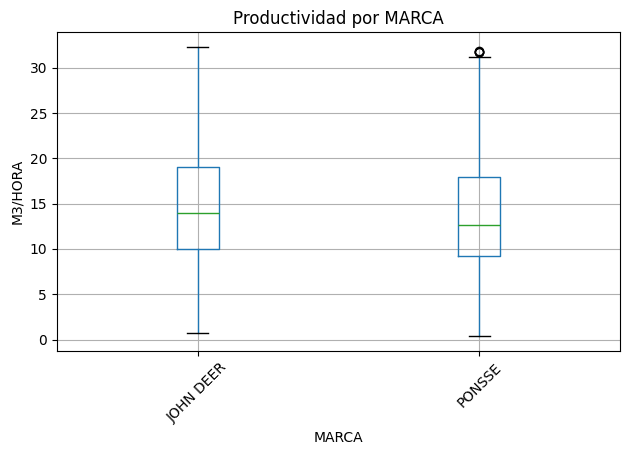

<Figure size 1100x500 with 0 Axes>

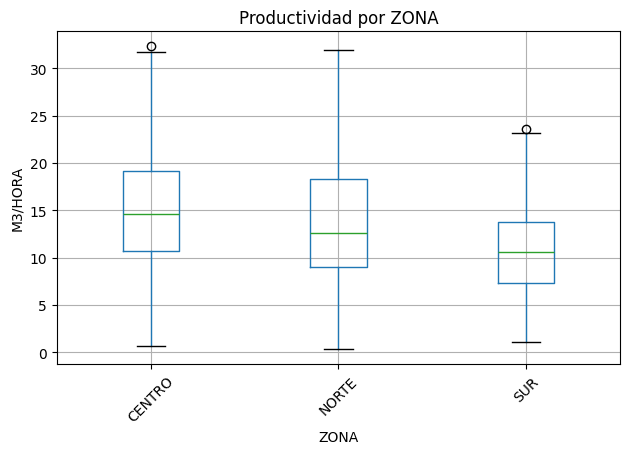

<Figure size 1100x500 with 0 Axes>

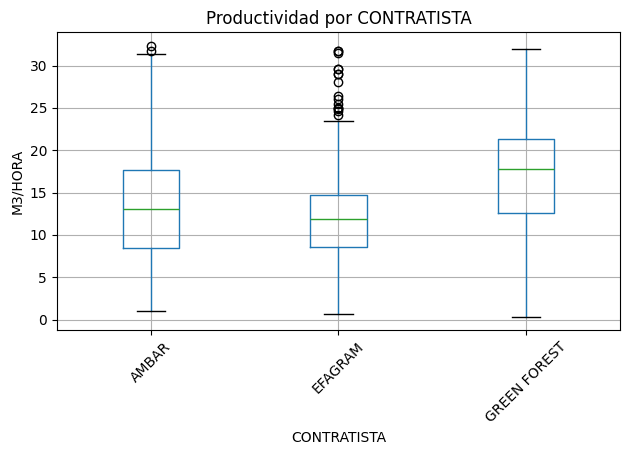

<Figure size 1100x500 with 0 Axes>

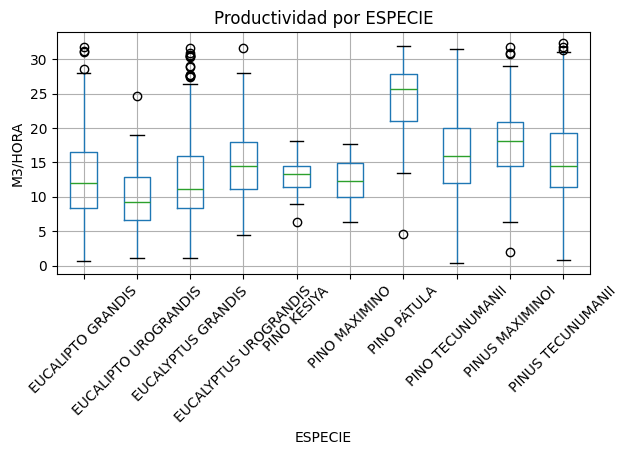

<Figure size 1100x500 with 0 Axes>

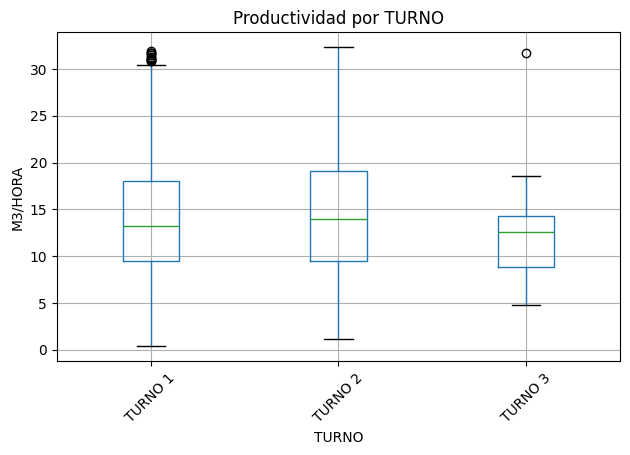

<Figure size 1100x500 with 0 Axes>

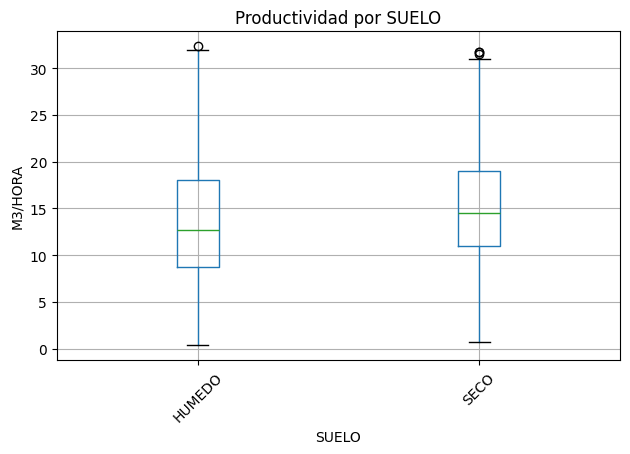

In [14]:
for col in variables_categoricas:
    top_categorias = df_model[col].value_counts().head(12).index
    data_plot = df_model[df_model[col].isin(top_categorias)].copy()

    plt.figure(figsize=(11,5))
    data_plot.boxplot(column=target, by=col, rot=45)
    plt.title(f"Productividad por {col}")
    plt.suptitle("")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.tight_layout()
    plt.show()


## 15. Análisis categórico vs categórico
Este bloque complementa el EDA revisando relaciones entre variables categóricas. Sirve para detectar sesgos operativos antes del preprocesamiento, por ejemplo equipos concentrados en ciertas zonas o contratistas asociados a determinados equipos.

In [15]:
# Función auxiliar para analizar la relación entre dos variables categóricas
# Se usa proporción por fila para interpretar la distribución relativa de cada categoría.

def analizar_categoricas(data, fila, columna, top_fila=12, top_columna=12):
    base = data[[fila, columna]].dropna().copy()

    # Para que las tablas y gráficos sean legibles se muestran las categorías más frecuentes.
    filas_top = base[fila].value_counts().head(top_fila).index
    columnas_top = base[columna].value_counts().head(top_columna).index
    base = base[base[fila].isin(filas_top) & base[columna].isin(columnas_top)]

    tabla_frecuencia = pd.crosstab(base[fila], base[columna])
    tabla_proporcion = pd.crosstab(base[fila], base[columna], normalize="index")

    print(f"Relación categórica: {fila} vs {columna}")
    print(f"Registros analizados: {len(base):,}")
    display(tabla_frecuencia)
    display(tabla_proporcion.round(3))

    ax = tabla_proporcion.plot(kind="bar", stacked=True, figsize=(11,5))
    ax.set_title(f"Distribución proporcional de {columna} por {fila}")
    ax.set_xlabel(fila)
    ax.set_ylabel("Proporción")
    ax.legend(title=columna, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return tabla_frecuencia, tabla_proporcion


### 15.1 Equipo vs zona
Este análisis permite revisar si algunos equipos trabajan principalmente en zonas específicas. Si ocurre, la comparación de productividad por equipo puede estar influida por la zona donde opera.

Relación categórica: EQUIPO vs ZONA
Registros analizados: 1,221


ZONA,CENTRO,NORTE,SUR
EQUIPO,,,
HVJD-1,17,0,105
HVJD-2,162,0,0
HVJD-3,100,0,0
HVJD-4,133,0,0
HVJD-5,170,0,0
HVPO-1,0,100,0
HVPO-2,0,91,0
HVPO-3,0,124,0
HVPO-4,53,26,0


ZONA,CENTRO,NORTE,SUR
EQUIPO,,,
HVJD-1,0.139,0.000,0.861
HVJD-2,1.000,0.000,0.000
HVJD-3,1.000,0.000,0.000
HVJD-4,1.000,0.000,0.000
HVJD-5,1.000,0.000,0.000
HVPO-1,0.000,1.000,0.000
HVPO-2,0.000,1.000,0.000
HVPO-3,0.000,1.000,0.000
HVPO-4,0.671,0.329,0.000


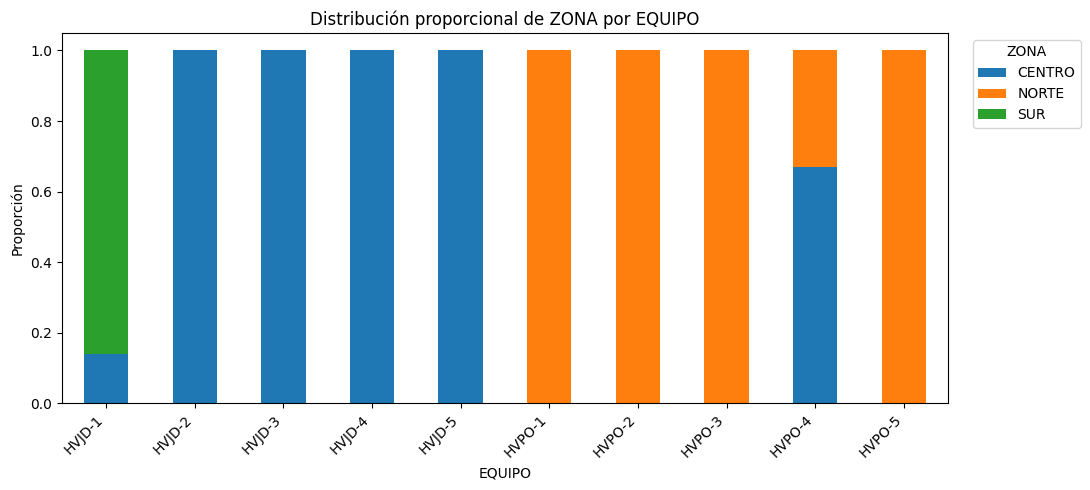

In [16]:
tabla_equipo_zona, prop_equipo_zona = analizar_categoricas(df_model, "EQUIPO", "ZONA")

### 15.2 Especie vs zona
Este análisis permite identificar si determinadas especies se concentran en zonas específicas, lo cual puede afectar la productividad observada por condiciones de terreno, clima o logística.

Relación categórica: ESPECIE vs ZONA
Registros analizados: 1,221


ZONA,CENTRO,NORTE,SUR
ESPECIE,,,
EUCALIPTO GRANDIS,118,55,33
EUCALIPTO UROGRANDIS,1,84,10
EUCALYPTUS GRANDIS,143,111,52
EUCALYPTUS UROGRANDIS,67,0,10
PINO KESIYA,15,0,0
PINO MAXIMINO,4,17,0
PINO PÁTULA,0,48,0
PINO TECUNUMANII,148,46,0
PINUS MAXIMINOI,4,99,0


ZONA,CENTRO,NORTE,SUR
ESPECIE,,,
EUCALIPTO GRANDIS,0.573,0.267,0.160
EUCALIPTO UROGRANDIS,0.011,0.884,0.105
EUCALYPTUS GRANDIS,0.467,0.363,0.170
EUCALYPTUS UROGRANDIS,0.870,0.000,0.130
PINO KESIYA,1.000,0.000,0.000
PINO MAXIMINO,0.190,0.810,0.000
PINO PÁTULA,0.000,1.000,0.000
PINO TECUNUMANII,0.763,0.237,0.000
PINUS MAXIMINOI,0.039,0.961,0.000


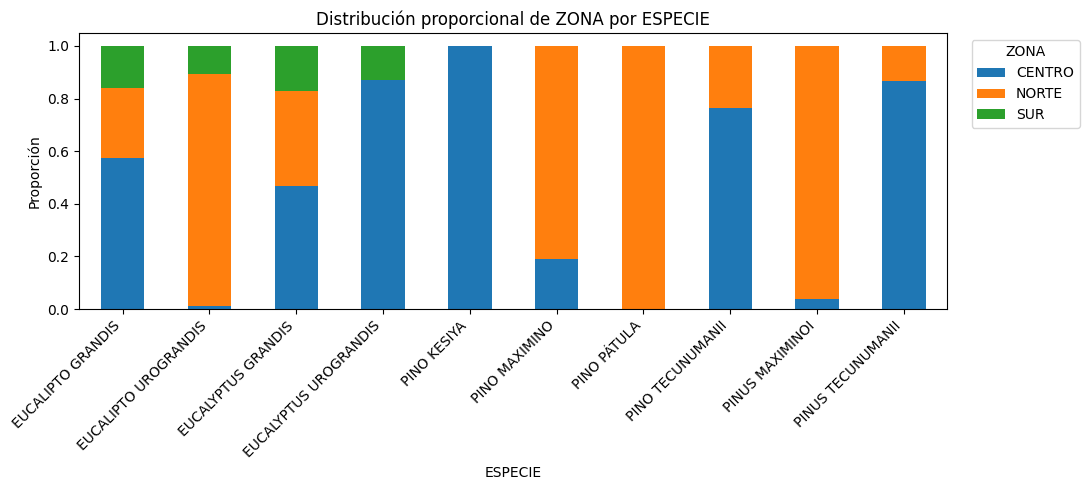

In [17]:
tabla_especie_zona, prop_especie_zona = analizar_categoricas(df_model, "ESPECIE", "ZONA")

### 15.3 Contratista vs equipo
Este análisis revisa si los contratistas operan con equipos específicos. Esto ayuda a evitar conclusiones simplistas sobre el desempeño del contratista o del equipo por separado.

Relación categórica: CONTRATISTA vs EQUIPO
Registros analizados: 1,221


EQUIPO,HVJD-1,HVJD-2,HVJD-3,HVJD-4,HVJD-5,HVPO-1,HVPO-2,HVPO-3,HVPO-4,HVPO-5
CONTRATISTA,,,,,,,,,,
AMBAR,122,0,0,133,0,0,0,0,0,0
EFAGRAM,0,162,100,0,0,0,91,124,53,0
GREEN FOREST,0,0,0,0,170,100,0,0,26,140


EQUIPO,HVJD-1,HVJD-2,HVJD-3,HVJD-4,HVJD-5,HVPO-1,HVPO-2,HVPO-3,HVPO-4,HVPO-5
CONTRATISTA,,,,,,,,,,
AMBAR,0.478,0.000,0.000,0.522,0.000,0.000,0.000,0.000,0.000,0.000
EFAGRAM,0.000,0.306,0.189,0.000,0.000,0.000,0.172,0.234,0.100,0.000
GREEN FOREST,0.000,0.000,0.000,0.000,0.390,0.229,0.000,0.000,0.060,0.321


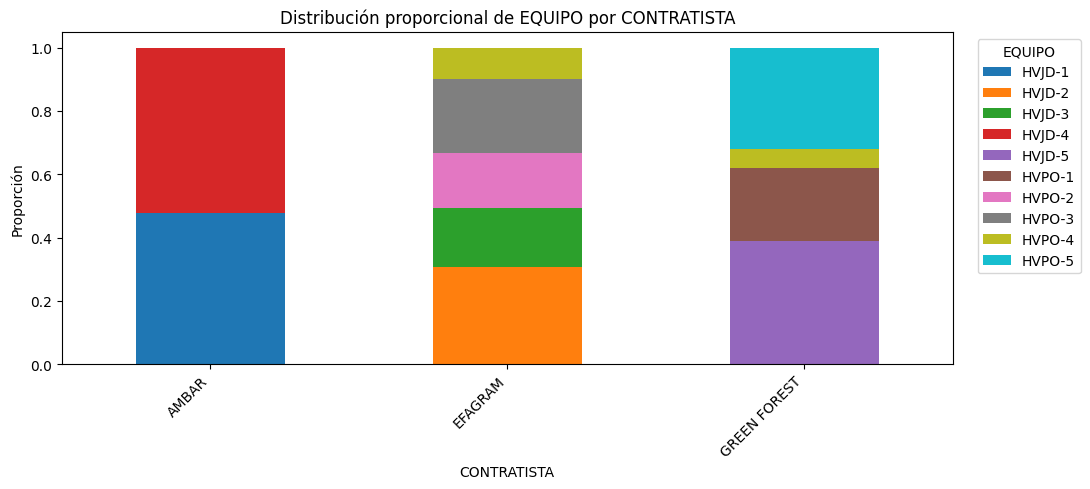

In [18]:
tabla_contratista_equipo, prop_contratista_equipo = analizar_categoricas(df_model, "CONTRATISTA", "EQUIPO")

### 15.4 Turno vs zona
Este análisis permite verificar si los turnos están distribuidos de forma homogénea entre zonas o si existe concentración operativa por ubicación.

Relación categórica: TURNO vs ZONA
Registros analizados: 1,221


ZONA,CENTRO,NORTE,SUR
TURNO,,,
TURNO 1,349,238,54
TURNO 2,275,234,51
TURNO 3,11,9,0


ZONA,CENTRO,NORTE,SUR
TURNO,,,
TURNO 1,0.544,0.371,0.084
TURNO 2,0.491,0.418,0.091
TURNO 3,0.550,0.450,0.000


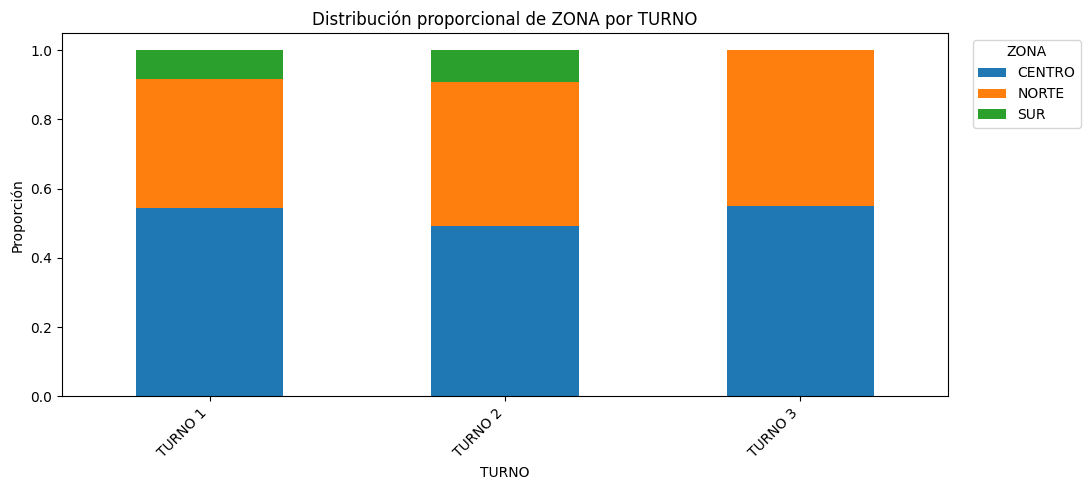

In [19]:
tabla_turno_zona, prop_turno_zona = analizar_categoricas(df_model, "TURNO", "ZONA")

### 15.5 Suelo vs zona
Este análisis permite observar si las condiciones de suelo se concentran en determinadas zonas. Esto es importante porque el suelo puede influir en movilidad, continuidad de operación y productividad.

Relación categórica: SUELO vs ZONA
Registros analizados: 1,200


ZONA,CENTRO,NORTE,SUR
SUELO,,,
HUMEDO,278,390,69
SECO,355,72,36


ZONA,CENTRO,NORTE,SUR
SUELO,,,
HUMEDO,0.377,0.529,0.094
SECO,0.767,0.156,0.078


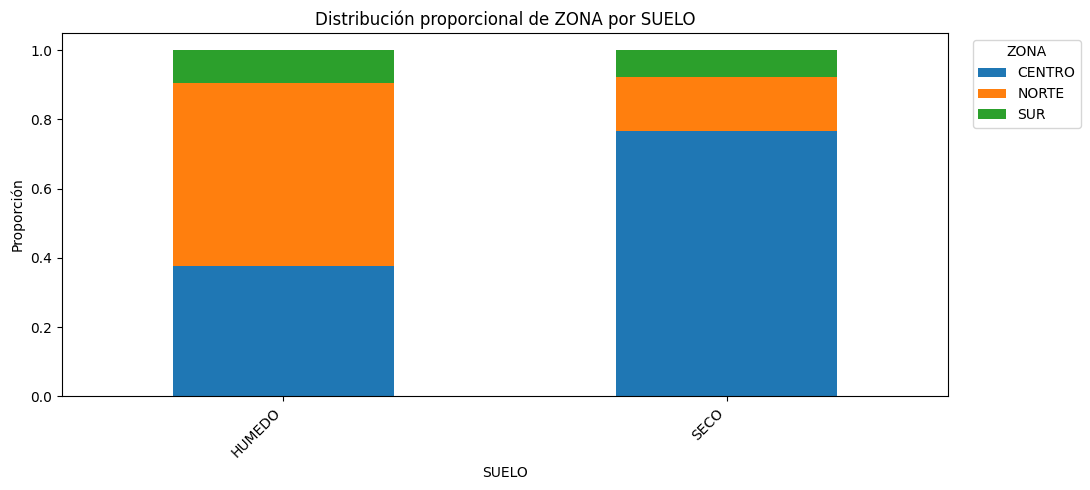

In [20]:
tabla_suelo_zona, prop_suelo_zona = analizar_categoricas(df_model, "SUELO", "ZONA")

### Conclusión del análisis categórico vs categórico
El análisis categórico vs categórico permite detectar dependencias estructurales entre variables de contexto. Estos hallazgos justifican la agrupación de categorías poco frecuentes y ayudan a interpretar el modelo con cautela: un equipo, contratista o especie puede mostrar mayor productividad no solo por su efecto propio, sino por las condiciones operativas donde se concentra.

## 16. Preprocesamiento: agrupación de categorías poco frecuentes
Se agrupan categorías con baja frecuencia en `OTROS` para reducir ruido, controlar sobreajuste y mejorar la estabilidad del modelo.


In [21]:
def agrupar_categorias_raras(data, columnas, min_registros=15):
    data = data.copy()
    mapa_categorias = {}

    for col in columnas:
        frecuencias = data[col].value_counts(dropna=True)
        categorias_validas = frecuencias[frecuencias >= min_registros].index
        data[col] = data[col].where(data[col].isin(categorias_validas), "OTROS")
        mapa_categorias[col] = list(categorias_validas)

    return data, mapa_categorias

df_model, mapa_categorias = agrupar_categorias_raras(
    df_model,
    variables_categoricas,
    min_registros=15
)

for col in variables_categoricas:
    print(col, "->", df_model[col].nunique(dropna=True), "categorías después de agrupar")


EQUIPO -> 10 categorías después de agrupar
MARCA -> 2 categorías después de agrupar
ZONA -> 3 categorías después de agrupar
CONTRATISTA -> 3 categorías después de agrupar
ESPECIE -> 10 categorías después de agrupar
TURNO -> 3 categorías después de agrupar
SUELO -> 3 categorías después de agrupar


## 17. Preprocesamiento: control de outliers en variables numéricas
Se aplica winsorización a predictores numéricos para reducir el efecto de valores extremos sin eliminar registros.


In [22]:
def winsorizar_columnas(data, columnas, p_inf=0.01, p_sup=0.99):
    data = data.copy()
    limites = {}

    for col in columnas:
        li = data[col].quantile(p_inf)
        ls = data[col].quantile(p_sup)
        data[col] = data[col].clip(lower=li, upper=ls)
        limites[col] = (li, ls)

    return data, limites

df_model, limites_winsor = winsorizar_columnas(df_model, variables_numericas)

pd.DataFrame(limites_winsor, index=["p01", "p99"]).T


,p01,p99
PENDIENTE PROMEDIO FINCA,14.458,35.087
TOTAL DE ARBOLES,23.000,859.660
DIAMETRO,0.185,288.000
T PROGRAMADO,6.300,12.000
HORAS DE OTRAS PARADA,0.330,7.338
clima_temp_promedio_dia_c,12.800,25.000
clima_temp_min_dia_c,10.040,20.100
clima_temp_max_dia_c,14.900,33.000
clima_precipitacion_dia_mm,0.100,35.600
clima_viento_promedio_dia_kmh,5.000,13.800


## 18. División entrenamiento-prueba
Se separan los datos para evaluar el modelo en registros que no fueron usados durante el entrenamiento.


In [23]:
X = df_model[variables_categoricas + variables_numericas].copy()
y = df_model[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (976, 17)
Prueba: (245, 17)


## 19. Pipeline de preprocesamiento
Las variables numéricas se imputan y estandarizan. Las categóricas se imputan y transforman con One-Hot Encoding.


In [24]:
pipeline_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipeline_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocesador = ColumnTransformer(transformers=[
    ("num", pipeline_numerico, variables_numericas),
    ("cat", pipeline_categorico, variables_categoricas)
])

model = Pipeline(steps=[
    ("preprocess", preprocesador),
    ("model", LinearRegression())
])

model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 20. Entrenamiento del modelo
Se ajusta una regresión lineal múltiple para explicar la productividad a partir de variables operativas y de contexto.


In [25]:
model.fit(X_train, y_train)
print("Modelo entrenado correctamente.")


Modelo entrenado correctamente.


## 21. Evaluación en entrenamiento y prueba
Se calculan MAE, RMSE y R² para revisar error promedio, errores grandes y capacidad explicativa.


In [26]:
def evaluar_modelo(modelo, X_data, y_real, nombre="datos"):
    y_pred = modelo.predict(X_data)
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    return pd.DataFrame({
        "conjunto": [nombre],
        "MAE": [mae],
        "RMSE": [rmse],
        "R2": [r2]
    })

metricas = pd.concat([
    evaluar_modelo(model, X_train, y_train, "Entrenamiento"),
    evaluar_modelo(model, X_test, y_test, "Prueba")
], ignore_index=True)

metricas


,conjunto,MAE,RMSE,R2
0,Entrenamiento,3.553,4.640,0.506
1,Prueba,3.869,5.010,0.431


## 22. Validación cruzada
La validación cruzada revisa si el desempeño es estable y no depende de una sola partición entrenamiento-prueba.


In [27]:
kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    model,
    X,
    y,
    cv=kf,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=False
)

resumen_cv = pd.DataFrame({
    "metrica": ["MAE", "RMSE", "R2"],
    "promedio": [
        -cv_results["test_MAE"].mean(),
        -cv_results["test_RMSE"].mean(),
        cv_results["test_R2"].mean()
    ],
    "desviacion": [
        cv_results["test_MAE"].std(),
        cv_results["test_RMSE"].std(),
        cv_results["test_R2"].std()
    ]
})

resumen_cv


,metrica,promedio,desviacion
0,MAE,3.705,0.264
1,RMSE,4.820,0.363
2,R2,0.464,0.054


## 23. Diagnóstico de residuos
Los residuos ayudan a revisar si el modelo comete errores sistemáticos o si los errores se distribuyen de forma razonable.


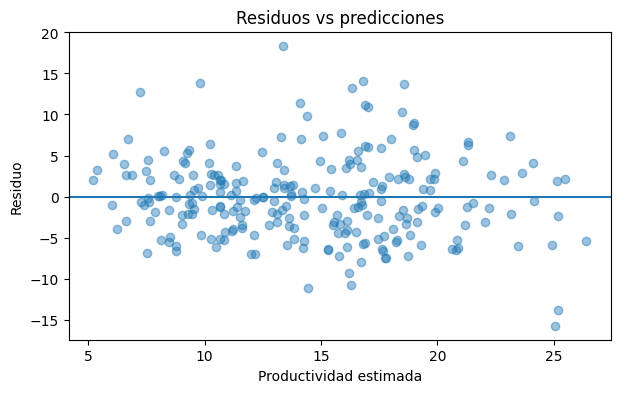

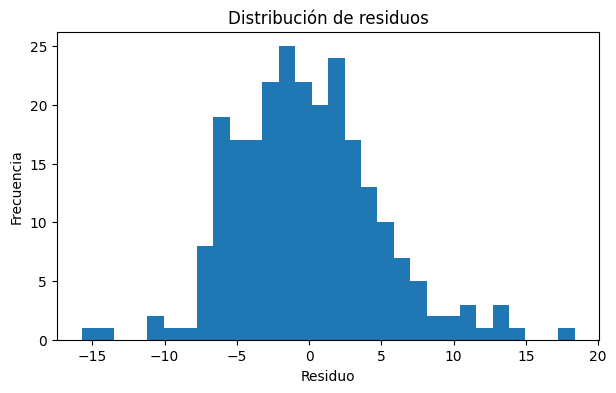

count   245.000
mean     -0.142
std       5.018
min     -15.739
25%      -3.504
50%      -0.511
75%       2.601
max      18.377
Name: M3/HORA, dtype: float64

In [28]:
y_pred_test = model.predict(X_test)
residuos = y_test - y_pred_test

plt.figure(figsize=(7,4))
plt.scatter(y_pred_test, residuos, alpha=0.45)
plt.axhline(0)
plt.title("Residuos vs predicciones")
plt.xlabel("Productividad estimada")
plt.ylabel("Residuo")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(residuos, bins=30)
plt.title("Distribución de residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()

pd.Series(residuos).describe()


## 24. Importancia de variables por permutación
Esta es la lectura principal para saber qué variables tienen más peso. Mide cuánto se deteriora el modelo cuando se altera una variable.


In [29]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error"
)

importancia_variables = pd.DataFrame({
    "variable": X_test.columns,
    "importancia_MAE": perm.importances_mean,
    "desviacion": perm.importances_std
}).sort_values(by="importancia_MAE", ascending=False)

importancia_variables


,variable,importancia_MAE,desviacion
8,TOTAL DE ARBOLES,1.549,0.176
0,EQUIPO,0.897,0.150
4,ESPECIE,0.713,0.116
12,clima_temp_promedio_dia_c,0.671,0.084
13,clima_temp_min_dia_c,0.481,0.077
14,clima_temp_max_dia_c,0.477,0.102
3,CONTRATISTA,0.302,0.084
2,ZONA,0.214,0.051
7,PENDIENTE PROMEDIO FINCA,0.046,0.027
10,T PROGRAMADO,0.023,0.023


## 25. Gráfico de importancia de variables
Mientras más alta la importancia, mayor peso tiene la variable en el desempeño predictivo del modelo.


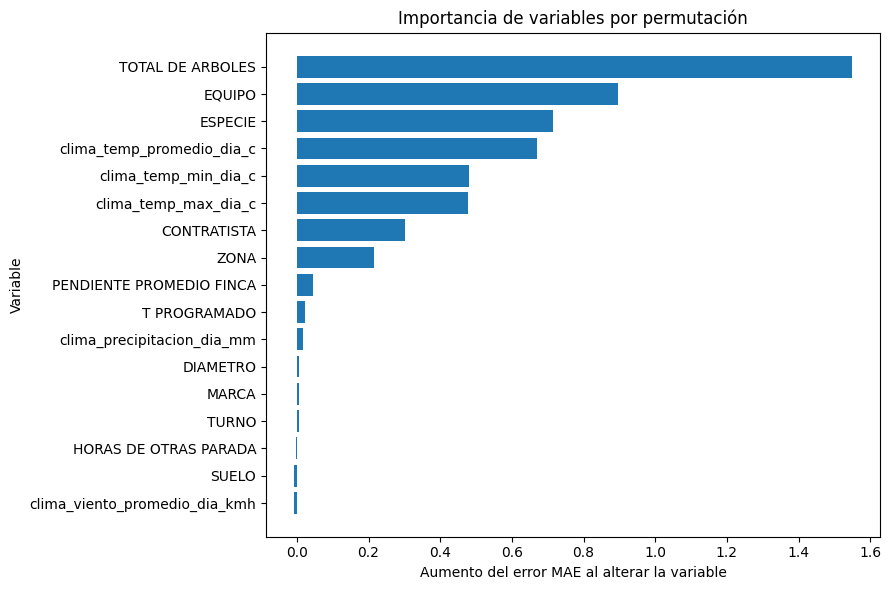

In [30]:
plot_imp = importancia_variables.sort_values("importancia_MAE", ascending=True)

plt.figure(figsize=(9,6))
plt.barh(plot_imp["variable"], plot_imp["importancia_MAE"])
plt.title("Importancia de variables por permutación")
plt.xlabel("Aumento del error MAE al alterar la variable")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


## 26. Coeficientes del modelo
Los coeficientes muestran dirección del efecto. Se usan como apoyo interpretativo, no como única medida de importancia.


In [31]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coeficientes = pd.DataFrame({
    "variable_transformada": feature_names,
    "coeficiente": model.named_steps["model"].coef_
})

coeficientes["variable_transformada"] = (
    coeficientes["variable_transformada"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top_coeficientes = pd.concat([
    coeficientes.sort_values("coeficiente", ascending=False).head(10),
    coeficientes.sort_values("coeficiente", ascending=True).head(10)
])

top_coeficientes


,variable_transformada,coeficiente
29,ESPECIE_PINO PÁTULA,10.071
12,EQUIPO_HVJD-4,8.623
31,ESPECIE_PINUS MAXIMINOI,5.689
32,ESPECIE_PINUS TECUNUMANII,5.301
23,CONTRATISTA_GREEN FOREST,4.374
28,ESPECIE_PINO MAXIMINO,4.009
10,EQUIPO_HVJD-2,3.897
21,ZONA_SUR,3.688
30,ESPECIE_PINO TECUNUMANII,3.332
13,EQUIPO_HVJD-5,3.055


## 27. Respuesta a la pregunta de negocio
La regresión lineal permite identificar qué variables operativas y de contexto influyen más en la productividad. La importancia por permutación indica peso predictivo; los coeficientes indican dirección e interpretación relativa.


In [32]:
print("Variables con mayor peso según importancia por permutación:")
display(importancia_variables.head(10))

print("Coeficientes positivos y negativos más fuertes:")
display(top_coeficientes)


Variables con mayor peso según importancia por permutación:


,variable,importancia_MAE,desviacion
8,TOTAL DE ARBOLES,1.549,0.176
0,EQUIPO,0.897,0.150
4,ESPECIE,0.713,0.116
12,clima_temp_promedio_dia_c,0.671,0.084
13,clima_temp_min_dia_c,0.481,0.077
14,clima_temp_max_dia_c,0.477,0.102
3,CONTRATISTA,0.302,0.084
2,ZONA,0.214,0.051
7,PENDIENTE PROMEDIO FINCA,0.046,0.027
10,T PROGRAMADO,0.023,0.023


Coeficientes positivos y negativos más fuertes:


,variable_transformada,coeficiente
29,ESPECIE_PINO PÁTULA,10.071
12,EQUIPO_HVJD-4,8.623
31,ESPECIE_PINUS MAXIMINOI,5.689
32,ESPECIE_PINUS TECUNUMANII,5.301
23,CONTRATISTA_GREEN FOREST,4.374
28,ESPECIE_PINO MAXIMINO,4.009
10,EQUIPO_HVJD-2,3.897
21,ZONA_SUR,3.688
30,ESPECIE_PINO TECUNUMANII,3.332
13,EQUIPO_HVJD-5,3.055


## 28. Simulador de escenarios
El simulador compara equipos manteniendo constantes las demás condiciones. Así se evita concluir que un equipo es mejor sin controlar zona, especie, suelo, turno y demás variables.


In [33]:
def valor_tipico_escenario(data, variables_cat, variables_num):
    escenario = {}

    for col in variables_cat:
        moda = data[col].mode(dropna=True)
        escenario[col] = moda.iloc[0] if len(moda) > 0 else "OTROS"

    for col in variables_num:
        escenario[col] = data[col].median()

    return escenario

escenario_base = valor_tipico_escenario(df_model, variables_categoricas, variables_numericas)
escenario_base


{'EQUIPO': 'HVJD-5',
 'MARCA': 'JOHN DEER',
 'ZONA': 'CENTRO',
 'CONTRATISTA': 'EFAGRAM',
 'ESPECIE': 'EUCALYPTUS GRANDIS',
 'TURNO': 'TURNO 1',
 'SUELO': 'HUMEDO',
 'PENDIENTE PROMEDIO FINCA': np.float64(19.234154182394327),
 'TOTAL DE ARBOLES': np.float64(233.0),
 'DIAMETRO': np.float64(20.0),
 'T PROGRAMADO': np.float64(8.0),
 'HORAS DE OTRAS PARADA': np.float64(1.663333333333333),
 'clima_temp_promedio_dia_c': np.float64(16.6),
 'clima_temp_min_dia_c': np.float64(13.9),
 'clima_temp_max_dia_c': np.float64(21.6),
 'clima_precipitacion_dia_mm': np.float64(11.4),
 'clima_viento_promedio_dia_kmh': np.float64(7.6)}

## 29. Ajuste manual del escenario
Modifica estos valores para simular una operación específica. El modelo comparará los equipos bajo estas mismas condiciones.


In [34]:
escenario_usuario = escenario_base.copy()

escenario_usuario.update({
    "MARCA": escenario_base["MARCA"],
    "ZONA": escenario_base["ZONA"],
    "CONTRATISTA": escenario_base["CONTRATISTA"],
    "ESPECIE": escenario_base["ESPECIE"],
    "TURNO": escenario_base["TURNO"],
    "SUELO": escenario_base["SUELO"],
    "PENDIENTE PROMEDIO FINCA": escenario_base["PENDIENTE PROMEDIO FINCA"],
    "TOTAL DE ARBOLES": escenario_base["TOTAL DE ARBOLES"],
    "DIAMETRO": escenario_base["DIAMETRO"],
    "T PROGRAMADO": escenario_base["T PROGRAMADO"],
    "HORAS DE OTRAS PARADA": escenario_base["HORAS DE OTRAS PARADA"],
    "clima_temp_promedio_dia_c": escenario_base["clima_temp_promedio_dia_c"],
    "clima_temp_min_dia_c": escenario_base["clima_temp_min_dia_c"],
    "clima_temp_max_dia_c": escenario_base["clima_temp_max_dia_c"],
    "clima_precipitacion_dia_mm": escenario_base["clima_precipitacion_dia_mm"],
    "clima_viento_promedio_dia_kmh": escenario_base["clima_viento_promedio_dia_kmh"],
})

escenario_usuario


{'EQUIPO': 'HVJD-5',
 'MARCA': 'JOHN DEER',
 'ZONA': 'CENTRO',
 'CONTRATISTA': 'EFAGRAM',
 'ESPECIE': 'EUCALYPTUS GRANDIS',
 'TURNO': 'TURNO 1',
 'SUELO': 'HUMEDO',
 'PENDIENTE PROMEDIO FINCA': np.float64(19.234154182394327),
 'TOTAL DE ARBOLES': np.float64(233.0),
 'DIAMETRO': np.float64(20.0),
 'T PROGRAMADO': np.float64(8.0),
 'HORAS DE OTRAS PARADA': np.float64(1.663333333333333),
 'clima_temp_promedio_dia_c': np.float64(16.6),
 'clima_temp_min_dia_c': np.float64(13.9),
 'clima_temp_max_dia_c': np.float64(21.6),
 'clima_precipitacion_dia_mm': np.float64(11.4),
 'clima_viento_promedio_dia_kmh': np.float64(7.6)}

## 30. Ranking de equipos según escenario
Se cambia únicamente el equipo y se mantiene constante el resto de variables. El mayor valor estimado representa el mejor equipo para ese escenario específico.


In [35]:
def comparar_equipos(modelo, data, escenario, equipo_col="EQUIPO"):
    equipos = sorted(data[equipo_col].dropna().unique())
    resultados = []

    for equipo in equipos:
        fila = escenario.copy()
        fila[equipo_col] = equipo
        X_sim = pd.DataFrame([fila])[variables_categoricas + variables_numericas]
        pred = modelo.predict(X_sim)[0]
        resultados.append({
            "EQUIPO": equipo,
            "PRODUCTIVIDAD_ESTIMADA_M3_H": pred
        })

    return pd.DataFrame(resultados).sort_values(
        by="PRODUCTIVIDAD_ESTIMADA_M3_H",
        ascending=False
    ).reset_index(drop=True)

ranking_equipos = comparar_equipos(model, df_model, escenario_usuario)
ranking_equipos


,EQUIPO,PRODUCTIVIDAD_ESTIMADA_M3_H
0,HVJD-4,19.993
1,HVJD-2,15.267
2,HVJD-5,14.425
3,HVPO-4,14.249
4,HVPO-5,11.895
5,HVJD-3,11.711
6,HVJD-1,11.370
7,HVPO-2,10.592
8,HVPO-1,10.506
9,HVPO-3,9.716


## 31. Visualización del ranking de equipos
El gráfico permite comparar rápidamente los equipos para el escenario definido.


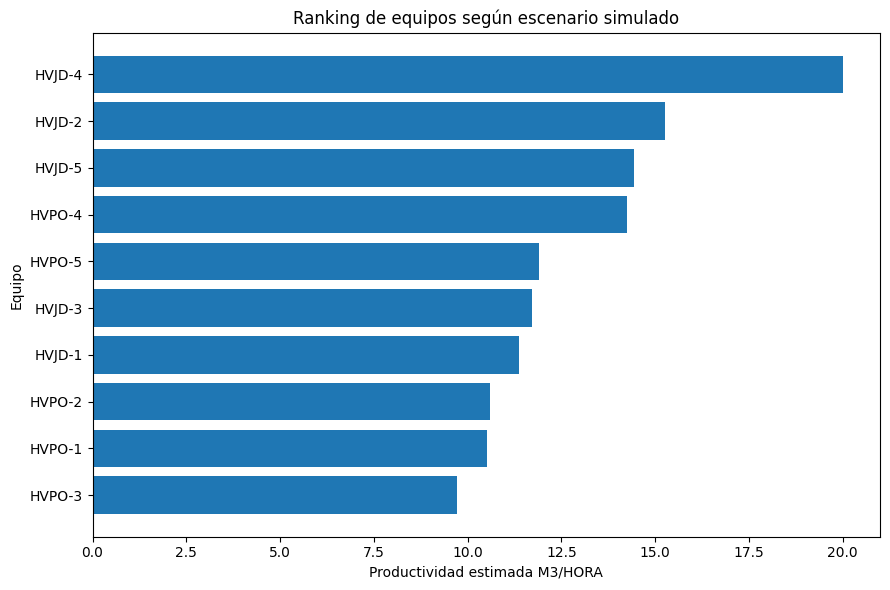

In [36]:
top_ranking = ranking_equipos.head(15).sort_values("PRODUCTIVIDAD_ESTIMADA_M3_H", ascending=True)

plt.figure(figsize=(9,6))
plt.barh(top_ranking["EQUIPO"], top_ranking["PRODUCTIVIDAD_ESTIMADA_M3_H"])
plt.title("Ranking de equipos según escenario simulado")
plt.xlabel("Productividad estimada M3/HORA")
plt.ylabel("Equipo")
plt.tight_layout()
plt.show()


## 32. Interpretación del simulador
El simulador no dice que un equipo sea universalmente mejor. Indica cuál equipo tendría mayor productividad esperada bajo un conjunto específico de condiciones operativas.

La lectura correcta es:

- Si se mantienen constantes zona, contratista, especie, turno, suelo, pendiente, árboles, diámetro, tiempo programado, paradas y clima, el ranking compara el efecto esperado de cambiar únicamente el equipo.
- Si cambia el escenario, puede cambiar el mejor equipo.
- La decisión operativa debe combinar la predicción con experiencia técnica, disponibilidad de maquinaria y restricciones reales de campo.


## 33. Conclusión técnica
Esta versión v8 fortalece el análisis porque:

1. Usa variables definidas por criterio de negocio.
2. Realiza EDA antes de modelar.
3. Controla datos faltantes, categorías raras y valores extremos.
4. Evalúa el modelo con prueba y validación cruzada.
5. Usa importancia por permutación para determinar variables con más peso.
6. Incluye un simulador para comparar equipos bajo condiciones equivalentes.

Con esto, la regresión lineal pasa de ser un ejercicio predictivo a una herramienta de interpretación y apoyo a decisiones operativas.
